### Welcome to Machine Learning: The Big Picture
Ye code jo aapne share kiya hai, wo **Unsupervised Learning** ka ek classic example hai. Humare paas 0 se 9 tak ke handwritten numbers (digits) ki bohot sari images hain. Par hum computer ko ye nahi bata rahe hain ki konsi image '1' ki hai ya konsi '2' ki hai. 

Hum bas computer ko images de rahe hain aur bol rahe hain: **"Bhai, inme se jo images ek jaisi dikhti hain, unka group bana de. Mujhe 10 groups chahiye (kyunki digits 0-9 hote hain)."** Ise **Clustering** kehte hain, aur yahan hum **K-Means Clustering** algorithm ka use kar rahe hain.

---

### Step 1: Libraries Import Karna (The Tools)

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
```

#### Inka kya kaam hai?
* **numpy (np):** Ye Python mein numbers aur arrays (matrix) ke sath complex math karne ke liye use hota hai.
* **pandas (pd):** Data ko tables (rows & columns) mein dekhne aur handle karne ke liye (halanki is code mein ye use nahi hua hai, par standard practice mein import kar lete hain).
* **matplotlib.pyplot (plt):** Ye graph aur images draw karne ka tool hai. Jo final images aapko dikhengi, wo yahi draw karega.
* **sklearn (Scikit-Learn):** Ye Machine learning ki sabse popular library hai. Iske andar se humne alag-alag tools mangwaye hain:
    * **KMeans:** Wo algorithm jo groups banayega.
    * **load_digits:** Ye bana banaya dataset hai jisme digits ki images hain.
    * **silhouette_score:** Ye check karne ke liye hota hai ki groups kitne acche bane .
    * **MinMaxScaler:** Data ki values ko ek choti range (0 se 1) ke beech lane ke liye.
    * **Pipeline:** Multiple steps (jaise pehle scale karo, fir cluster karo) ko ek chain mein jodne ke liye.

---

### Step 2: Data Load Karna (Background Logic & Math)

```python
digits = load_digits()
```

#### Logic:
* Computer ko images nahi dikhti, use sirf numbers samajh aate hain. `load_digits()` mein har ek digit ki image ek 8x8 pixel ka grid (box) hai.
* 8 row aur 8 column = Total 64 pixels.
* Har pixel ek number hota hai jo batata hai ki wahan kitna dark (black) color hai. 0 matlab pura white, aur 16 matlab pura black.
* `digits.data` mein ye 8x8 ki image ko seedha ek lambi line mein khol diya gaya hai. Toh ek image 64 numbers ka ek array (list) ban jati hai. Agar 1797 images hain, toh data ka shape $(1797, 64)$ hoga.

---

### Step 3: KMeans Ke Parameters Setup Karna (The Rules)

```python
kmeans_kwargs = {
    "init": "random",
    "n_init": 50,
    "max_iter": 500,
    "random_state": 0,
}
```

KMeans ek mathematical algorithm hai jo koshish karke groups banata hai. Hum usko dictionary `kmeans_kwargs` ke zariye rules bata rahe hain.

#### Inka logic kya hai?
* **init: "random"** -> KMeans apne shuruati 10 center points (centroids) bilkul random jagah par rakhega.
* **n_init: 50** -> KMeans apni process ko 50 alag-alag random points se try karega, aur unme se jo sabse best result dega usko final manega. Kyun? Kyunki kabhi kabhi galat jagah se start karne pe groups kharab ban jate hain.
* **max_iter: 500** -> KMeans apne centers ko adjust karta rehta hai. Ye rule kehta hai ki zyada se zyada 500 baar adjust karna, uske baad ruk jana agar answer na mile toh.
* **random_state: 0** -> Randomness ko fix karne ke liye. Agar aap 0 daloge, toh har baar code run karne pe same "random" points milenge taki results change na hon.

---

### Step 4: Pipeline Banana (The Assembly Line)

```python
pipeline = Pipeline([
    ("preprocess" , MinMaxScaler()),
    ("clustring" , KMeans(n_clusters=10 , **kmeans_kwargs))
])
```

#### Logic of Pipeline:
Pipeline ek factory belt ki tarah hai. Data pehle step mein jayega, wahan process hoga, aur fir automatically dusre step mein chala jayega.

#### Step 4.1: MinMaxScaler (Data Scaling)
Images ke pixels ki value 0 se 16 ke beech hai. `MinMaxScaler` in values ko dabakar 0 se 1 ke beech le aayega.
* **Math Logic:** K-Means algorithm distance (doori) par kaam karta hai. Agar numbers bade chote honge, toh calculation mein bias aa sakta hai. Scale karne se sab fair ho jata hai.
* **Formula used internally:** $X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$
* *(Example: Agar pixel value 8 hai. $X_{min} = 0$, $X_{max} = 16$. Toh $X_{scaled} = \frac{8 - 0}{16 - 0} = 0.5$)*

#### Step 4.2: KMeans (The Brain)
`n_clusters=10` matlab hume 10 groups chahiye (digits 0-9). `kmeans_kwargs` us dictionary ko kholkar yahan parameters pass kar deta hai.

---

### Step 5: Model ko Data Par Train Karna (The Math in Action)

```python
pipeline.fit(digits.data)
```
Ye sabse important line hai. Yahan actual Machine Learning ho rahi hai. Data pipeline mein gaya, scale hua, aur fir KMeans ne usko 10 groups mein baat diya.

#### KMeans ke andar ki Maths (Advance Concept):
1. **Centroids Initialization:** Algorithm 64-dimensional space (kyunki 64 pixels hain) mein 10 random points (centers) chunta hai.
2. **Distance Calculation:** Har ek image (data point) ka in 10 centers se distance nikala jata hai. Distance nikalne ke liye Euclidean distance formula use hota hai:
$$d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$$
3. **Assignment:** Image us center ke group mein chali jati hai jo uske sabse kareeb hota hai.
4. **Update:** Jab sab images 10 groups mein bant jati hain, toh algorithm har group ke andar ki sari images ka average (mean) nikalta hai aur center ko us nayi average position pe shift kar deta hai.
5. Ye steps tab tak repeat hote hain (max 500 baar) jab tak centers move hona band na kar dein.

---

### Step 6: Cluster Centers ko Bahar Nikalna

```python
cluster_center = pipeline[-1].cluster_centers_
```

#### Logic:
* `pipeline[-1]` ka matlab hai pipeline ka aakhiri step (jo ki KMeans hai).
* `.cluster_centers_` wo 10 final points hain jo KMeans ne dhundhe hain.
* Maje ki baat ye hai ki ye 10 points asal mein "Average Images" hain un sabhi numbers ki jo us group mein aaye hain. Ek center array bhi 64 length ka hoga (kyunki input 64 ka tha).

---

### Step 7: Un Centers ko Draw Karna (Visualization)

```python
fig , ax = plt.subplots(5 , 2 , figsize=(4,4))
for i , j in zip(ax.flat , cluster_center.reshape(10 , 8 , 8)):
    i.imshow(j)
```

#### Logic:
* `plt.subplots(5 , 2 , figsize=(4,4))`: Ye 5 rows aur 2 columns ka ek grid (khali frame) banata hai. Total $5 \times 2 = 10$ khali dabbe ban gaye kyuunki hamare paas 10 clusters hain.
* `cluster_center.reshape(10 , 8 , 8)`: Yaad hai shuru mein 8x8 image ko 64 lambi line banaya tha? Plot karne ke liye hume wapas usko 8x8 ka dabbe (matrix) wala shape dena hoga. Ye command 10 centers ko 8x8 ke box shape mein badal deti hai.
* `for i , j in zip(ax.flat , ...)`: Ye ek loop hai jo ek-ek khali dabbe (i) aur ek-ek image (j) ko uthata hai.
* `i.imshow(j)`: Ye actual mein image draw karne ka function hai. Isse hume pata chalta hai ki algorithm ko ek particular digit (jaise '3') kis tarah dikh raha hai (jo sabhi '3' jaisi dikhne wali images ka average hai).

---

### Summary
Aapne raw image data liya, math se usko standard range mein laye, geometry (KMeans) se unki similarity ke hisab se 10 centroid dhundhe, aur finally unn centroids (jo essentially mean images hain) ko screen pe draw kar diya!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from sklearn.datasets import load_digits

from sklearn.metrics import silhouette_score

from sklearn.preprocessing import MinMaxScaler

from sklearn.pipeline import Pipeline

### Clustring of Digits

In [2]:
digits = load_digits()

In [3]:
?KMeans

Init signature:
KMeans(
    n_clusters=8,
    *,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm='lloyd',
)
Docstring:     
K-Means clustering.

Read more in the :ref:`User Guide <k_means>`.

Parameters
----------

n_clusters : int, default=8
    The number of clusters to form as well as the number of
    centroids to generate.

    For an example of how to choose an optimal value for `n_clusters` refer to
    :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.

init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
    Method for initialization:

    * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to the overall inertia. This technique speeds up             convergence. The algorithm imple

In [4]:
kmeans_kwargs = {
    "init": "random",
    "n_init": 50,
    "max_iter": 500,
    "random_state": 0,
}

In [5]:
pipeline = Pipeline([
    ("preprocess" , MinMaxScaler()),
    ("clustring" , KMeans(n_clusters=10 , **kmeans_kwargs))
])
pipeline.fit(digits.data)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clustring', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_exampl

In [6]:
cluster_center = pipeline[-1].cluster_centers_

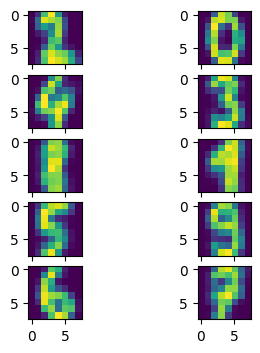

In [7]:
fig , ax = plt.subplots(5 , 2 , figsize=(4,4))
for i , j in zip(ax.flat , cluster_center.reshape(10 , 8 , 8)):
    i.imshow(j)


### Identifying the Correct Number of Clusters: The Elbow Method

**Elbow Method** ek technique hai jisse hum pata lagate hain ki K-Means algorithm ke liye kitne clusters ($k$) best rahenge. Iske liye hum $k$ ki alag-alag values try karte hain (jaise 1 se 11 tak) aur har baar dekhte hain ki model ne kitni "galti" (Error) ki hai. Jahaan par error girna achanak se slow ho jata hai (ek kohni ya elbow jaisi shape banti hai graph mein), wahi hamara best $k$ hota hai.

---

### Step 1: Error Track Karne Ke Liye Setup

```python
sse_digit = []
scaled_digits = MinMaxScaler().fit_transform(digits.data)
```

#### Logic:
* **`sse_digit = []`**: Humne ek khali list banayi hai. Jaise-jaise hum alag-alag $k$ try karenge, har model ki galti (SSE - Sum of Squared Error) hum is list mein save (append) karte jayenge.
* **`scaled_digits = ...`**: Jaise pichle code mein Pipeline ke andar humne data ko 0 se 1 ke beech scale kiya tha, yahan hum wahi step alag se kar rahe hain kyunki Elbow method lagane ke liye bhi scaled data chahiye.

---

### Step 2: Alag-alag 'k' Try Karna (The Loop)

```python
for k in range(1, 12):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_digits)
    sse_digit.append(kmeans.inertia_)
```

#### Logic:
* **`for k in range(1, 12):`**: Ye loop $k=1$ se lekar $k=11$ tak chalega. (Yaani pehle 1 cluster banayega, fir 2, fir 3... 11 tak).
* **`kmeans = KMeans(n_clusters=k, **kmeans_kwargs)`**: Har loop mein ek naya K-Means ka brain (model) ban raha hai jisme naye $k$ ki value dali ja rahi hai.
* **`kmeans.fit(scaled_digits)`**: Ye model ko data par train kar raha hai.
* **`sse_digit.append(kmeans.inertia_)`**: Ye sabse important line hai. `inertia_` K-Means ke andar ka ek variable hai jo **SSE (Sum of Squared Error)** ko store karta hai. Hum is galti ko apni khali list mein save kar rahe hain.

---

### The Math Behind SSE (Sum of Squared Error)

`inertia_` ya SSE akhir hai kya? 
Jab groups ban jate hain, toh har data point (image) apne group ke center (centroid) se kuch doori par hota hai. SSE in sabhi dooriyon ke square ka total (sum) hai. 

**Mathematical Formula:**
$$SSE = \sum_{i=1}^{k} \sum_{x \in C_i} (x - \mu_i)^2$$

* **$k$**: Total number of clusters.
* **$C_i$**: Ek specific group (cluster).
* **$x$**: Group ke andar ka ek data point.
* **$\mu_i$**: Us group ka center point (centroid).
* **Logic:** Agar error (SSE) bohot zyada hai, matlab data points apne center se bohot door hain (kharab clustering). Agar SSE kam hai, matlab points apne center ke paas hain (acchi clustering). Par agar hum $k$ ko itna badha dein jitne data points hain, toh SSE 0 ho jayega, jo ki overfitting hai. Isiliye hume ek balance chahiye!

---

### Step 3: Elbow Curve Draw Karna (Visualization)

```python
plt.plot(range(1, 12), sse_digit)
plt.xticks(range(1, 12))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()
```

#### Logic:
* **`plt.plot(...)`**: Ye line graph banayega. X-axis par humne 1 se 11 tak clusters ($k$) rakhe hain, aur Y-axis par humne unke SSE (errors) rakhe hain jo humne list mein jama kiye the.
* **`plt.xticks(...)`**: X-axis par numbers exactly 1, 2, 3... 11 dikhne chahiye.
* **`plt.xlabel` / `plt.ylabel`**: Graph ke axis ko naam dene ke liye.
* **`plt.show()`**: Graph ko screen par display karne ke liye.



### Graph Ko Kaise Padhein (How to find the Elbow)?
Jab aap graph dekhenge, toh wo shuru mein bohot tezi se niche girega (jaise 1 se lekar 5 tak). Par ek point aisa aayega jahan se error girna ekdam slow (flat) ho jayega. 

Ye graph ek insaan ke hath (arm) jaisa dikhta hai. Jis point par **"Kohni" (Elbow)** banti hai, wohi hamara perfect $k$ (number of clusters) hota hai. Digits wale data mein aapko kohni lagbhag **8, 9 ya 10** ke aas-paas banti hui dikhegi, jo prove karta hai ki hume 10 groups hi chahiye the!

In [8]:
#Identifying the correct number of clusters
sse_digit = [ ]

scaled_digits = MinMaxScaler().fit_transform(digits.data)
for k in range(1,12):
    kmeans = KMeans (n_clusters=k, ** kmeans_kwargs)
    kmeans.fit(scaled_digits)
    sse_digit.append(kmeans.inertia_)

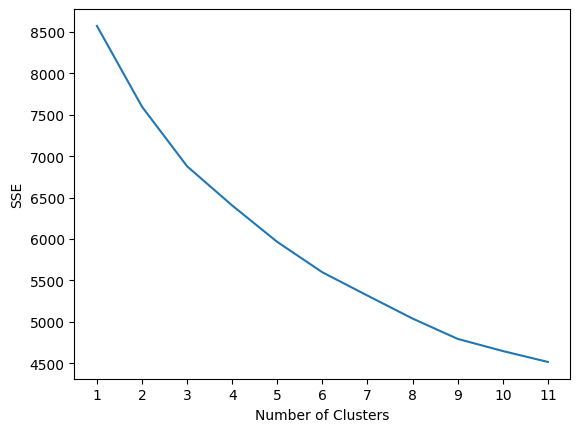

In [9]:
plt.plot(range(1, 12), sse_digit)
plt.xticks(range(1, 12))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

### Identifying the Correct Number of Clusters: The Silhouette Score Method

**Silhouette Score** ek tareeqa hai ye check karne ka ki jo clusters (groups) bane hain, wo kitne *acche* aur *alag* hain. Elbow method sirf galti (error) ko dekhta hai, par Silhouette Score do cheezein dekhta hai:
1. Ek image apne khud ke group ki baaki images ke kitne kareeb hai (Similarity).
2. Ek image dusre groups ki images se kitni door hai (Separation).

---

### Step 1: Silhouette Score Calculate Karna (The Loop)

```python
sil_coef_digits = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_digits)
    score = silhouette_score(digits.data, kmeans.labels_)
    sil_coef_digits.append(score)
```

#### Logic:
* **`sil_coef_digits = []`**: Har alag $k$ ke test ka final score yahan save hoga.
* **`for k in range(2, 15):`**: Dhyan dijiye, loop **2** se shuru ho raha hai, 1 se nahi! Kyun? Kyunki Silhouette Score do alag-alag groups ke beech ki doori naapta hai. Agar group hi sirf 1 hoga, toh usko kisse compare karenge? Isliye kam se kam 2 clusters hone zaroori hain. Ye loop 14 tak chalega.
* **`kmeans = KMeans(...)` & `kmeans.fit(...)`**: Har baar ek naya model ban raha hai aur data par train ho raha hai.
* **`score = silhouette_score(digits.data, kmeans.labels_)`**: Ye function score calculate karta hai. Isko do cheezein chahiye: original data (`digits.data`) aur KMeans ne unko jo group number (labels) diye hain wo (`kmeans.labels_`). 
* **`sil_coef_digits.append(score)`**: Jo score nikal kar aaya, usko humne apni list mein daal diya taki baad mein graph bana sakein.

---

### The Math Behind Silhouette Score (Advance Concept)

Silhouette score ka answer hamesha **-1 se +1** ke beech aata hai. Ise nikalne ka mathematical logic ek single data point $i$ ke liye kuch is tarah kaam karta hai:

1. **Cohesion ($a$)**: Data point $i$ ka apne hi group ke saare points se average distance. (Ye kam hona chahiye, yani sab paas-paas hone chahiye).
2. **Separation ($b$)**: Data point $i$ ka sabse kareebi *dusre* group ke saare points se average distance. (Ye zyada hona chahiye, yani dusra group door hona chahiye).

**Silhouette Score Formula:**
$$S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

#### Score ka Matlab (Meaning of the output):
* **Score +1 ke kareeb hai**: Excellent! Data point bilkul sahi group mein hai aur dusre group se bohot door hai.
* **Score 0 ke kareeb hai**: Overlapping! Data point do groups ke bilkul border par baitha hai.
* **Score -1 ke kareeb hai**: Wrong! Data point galat group mein chala gaya hai.

Pure dataset ka score nikalne ke liye saare $S(i)$ values ka average (mean) liya jata hai. Hum chahte hain ki hamara average score jitna zyada (+1 ke kareeb) ho, utna accha!



---

### Step 2: Silhouette Curve Draw Karna (Visualization)

```python
plt.plot(range(2,15), sil_coef_digits)
plt.xticks(range(2, 15))
plt.xlabel("Number of Clusters")
plt.ylabel("silhouette score")
plt.grid(True)
plt.show()
```

#### Logic:
* **`plt.plot(range(2,15), sil_coef_digits)`**: X-axis par humne 2 se 14 tak clusters ($k$) rakhe hain, aur Y-axis par unke calculated Silhouette Scores.
* **`plt.xticks(range(2, 15))`**: Taki X-axis par saare numbers clearly 2, 3, 4... 14 dikhein.
* **`plt.grid(True)`**: Ye ek nayi cheez hai jo background mein jaal (grid lines) bana deti hai. Isse graph ko padhna aur exact values dekhna aasan ho jata hai.
* **`plt.show()`**: Graph ko screen par display karne ke liye.

### Graph Ko Kaise Padhein (How to read this plot)?
Elbow method mein hum "Kohni" dhundhte the (jahan curve girna band ho jaye). Par Silhouette Score mein hume **Sabse Unchi Choti (Highest Peak)** dhundhni hoti hai. 

Jis $k$ (number of clusters) par aapko graph ka point sabse upar (highest score) milega, mathematical drishti se wahi aapke data ke liye sabse "best" number of clusters hai!

In [10]:
sil_coef_digits = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, ** kmeans_kwargs)
    kmeans.fit(scaled_digits)
    score = silhouette_score(digits.data, kmeans.labels_)
    sil_coef_digits.append(score)

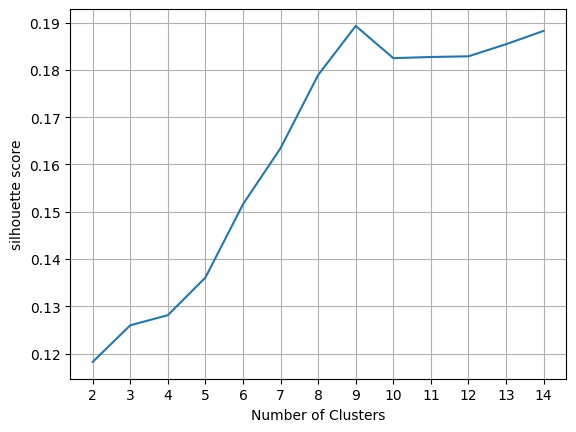

In [11]:
plt.plot(range(2, 15), sil_coef_digits)
plt.xticks(range(2,15))
plt.xlabel("Number of Clusters")
plt.ylabel("silhouette score")
plt.grid(True)
plt.show()